# Dataset Description

## Source
This dataset is a Credit Card Fraud dataset. Link:
https://www.kaggle.com/datasets/dhruvb2028/credit-card-fraud-dataset

## Problem Context
The real-world problem relates to predicting fraudulent credit card transactions. Fraud causes significant financial losses, requiring banks to have automated systems to detect illegitimate transactions. The classification target is `is_fraud` (where 1 indicates a fraudulent transaction, and 0 is legitimate).

## Features Description
*   `trans_date_trans_time`: (Datetime) The date and time of the transaction.
*   `merchant`: (String) The name of the merchant.
*   `category`: (String) The category of the transaction.
*   `amt`: (Float) The transaction amount in dollars.
*   `city`: (String) The city of the credit card holder.
*   `state`: (String) The state of the credit card holder.
*   `lat` / `long`: (Float) The latitude and longitude of the credit card holder's location.
*   `city_pop`: (Integer) The population of the city.
*   `job`: (String) The job title of the credit card holder.
*   `dob`: (Date) The date of birth of the credit card holder.
*   `trans_num`: (String) A unique transaction identifier.
*   `merch_lat` / `merch_long`: (Float) The latitude and longitude of the merchant.
*   `is_fraud`: (Integer) The target variable (1 = Fraud, 0 = Legitimate).

## Dataset Statistics
*   Instances & Features: 339,607 instances and 14 features.
*   Class Distribution: Highly imbalanced. Legitimate transactions make up 99.48%, while Fraudulent transactions make up only 0.52%.


# I. Data Loading & Initial Exploration
* The dataset consists of 339,607 rows and 15 columns
* There are no missing values in the dataset
* Class imbalance: 0.52% of the transactions are fraudulent. This extreme imbalance justifies the use of SMOTE and F1-score evaluation.

Dataset shape: (339607, 15)

Missing values:
 trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Legit transactions: 337825
Fraud transactions: 1782
Fraud percentage: 0.52%


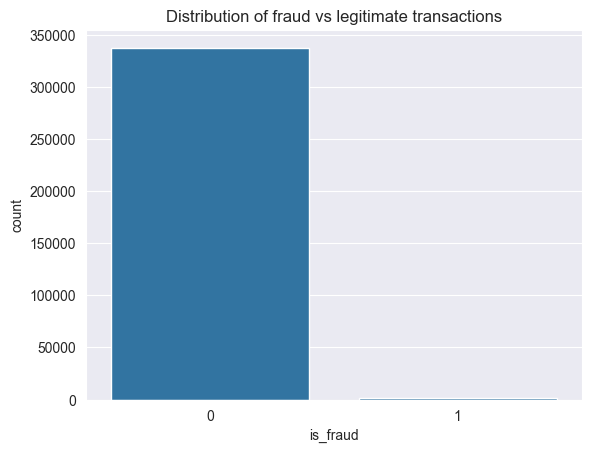

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
df = pd.read_csv('credit_card_frauds.csv')

# basic info
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

# class distribution
fraud_counts = df['is_fraud'].value_counts()
# identifies if the dataset is imbalanced
fraud_percentage = (fraud_counts[1] / len(df)) * 100 # ratio of fraud cases to total data

print(f"\nLegit transactions: {fraud_counts[0]}")
print(f"Fraud transactions: {fraud_counts[1]}")
print(f"Fraud percentage: {fraud_percentage:.2f}%")

# visualization
sns.countplot(x='is_fraud', data=df)
plt.title("Distribution of fraud vs legitimate transactions")
plt.show()

# 2. Exploratory data analysis
**The relationship between features and the target variable (`is_fraud`)**

* Transaction amount: The boxplot helps determine if fraudulent transactions have a different "typical" amount compared to legitimate ones. Fraudulent transactions often show a different distribution or higher median values in specific categories.
* Feature correlation: The heatmap is crucial for feature selection, as highly correlated features might be redundant, while features correlated with `is_fraud` are the best predictors.

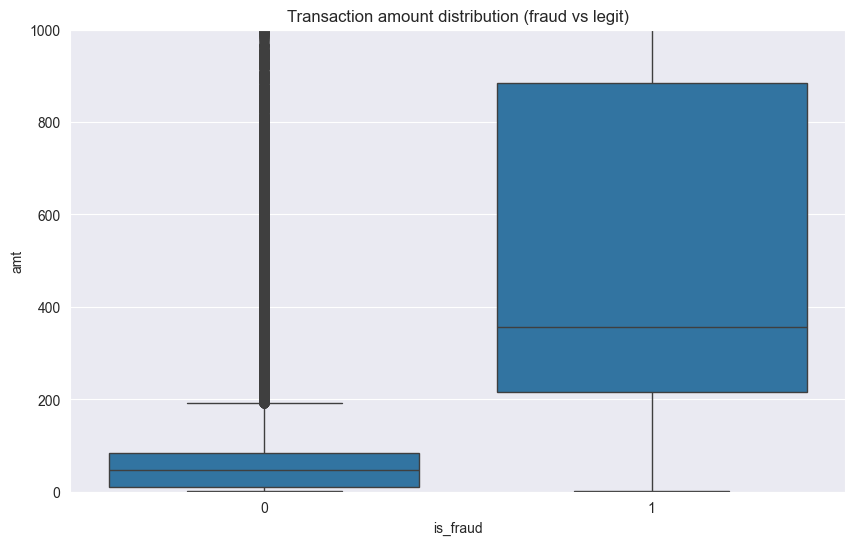

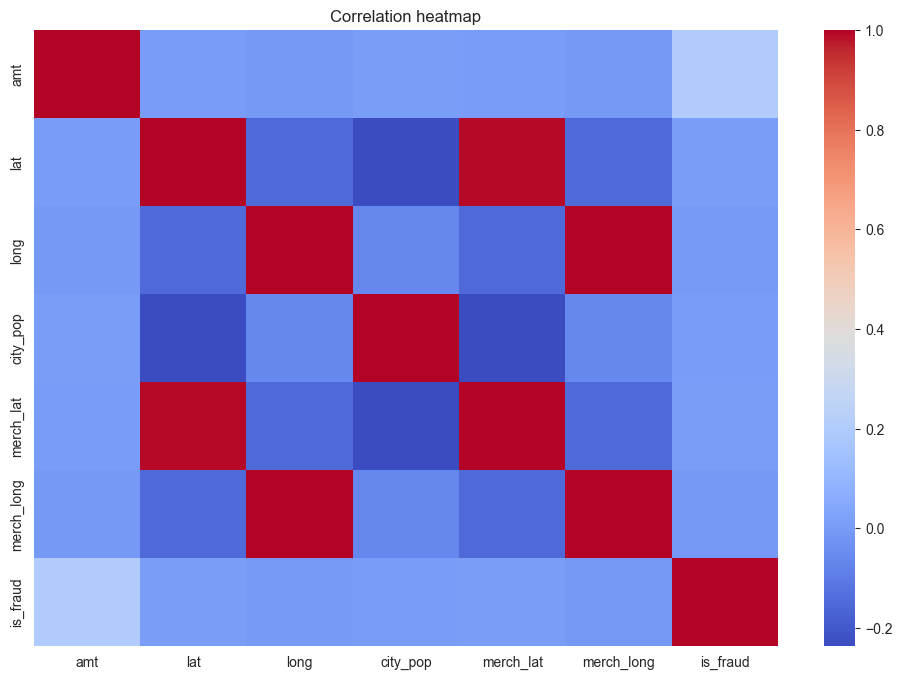

In [2]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title("Transaction amount distribution (fraud vs legit)")
plt.ylim(0, 1000)
plt.show()

plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation heatmap")
plt.show()

# 3. Data preprocessing, scaling & encoding
**Transforming the raw data into a format suitable for Machine Learning models. This involves creating new descriptive features, selecting the most relevant attributes and encoding categorical variables.**

New features:
* Distance: distance_km: distance between the customer and the merchant.
* Age: the customer's age at the time of transaction.
* Hour: the hour of the transaction helps identify temporal patterns, such as fraudulent activity occurring late at night.

I excluded high-cardinality features like `merchant`, `job`, and `trans_num` because they often lead to overfitting.

In [3]:
from math import radians, cos, sin, asin, sqrt

def distance(row):
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [row['long'], row['lat'], row['merch_long'], row['merch_lat']])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371 # radius of earth in kilometers
    return c * r

df['distance_km'] = df.apply(distance, axis=1)
# creates the actual distance_km values for the dataset

# calculate the age
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

df['hour'] = df['trans_date_trans_time'].dt.hour

# the list of features we want to keep
features = ['category', 'amt', 'city_pop', 'distance_km', 'age', 'hour', 'lat', 'long']
X = df[features]
y = df['is_fraud']

# one hot encoding on the category column.
X = pd.get_dummies(X, columns=['category'], drop_first=True)

print("Preprocessed features shape:", X.shape)
X.head()

Preprocessed features shape: (339607, 20)


,amt,city_pop,distance_km,age,hour,lat,long,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,107.23,149,30.212176,40,0,48.8878,-118.2105,False,False,False,True,False,False,False,False,False,False,False,False,False
1,220.11,4154,108.206083,56,0,42.1808,-112.2620,False,False,False,False,False,False,False,False,False,False,False,False,False
2,96.29,589,25.059079,73,0,41.6125,-122.5258,False,False,False,True,False,False,False,False,False,False,False,False,False
3,7.77,899,66.021685,51,0,32.9396,-105.8189,False,False,False,False,False,False,False,False,False,False,False,True,False
4,6.85,471,88.830984,51,0,43.0172,-111.0292,False,False,False,False,False,False,False,False,True,False,False,False,False


Visualisation of the distribution of fraudulent vs. legitimate transactions across a 24-hour cycle to justify the creation of the hour feature:

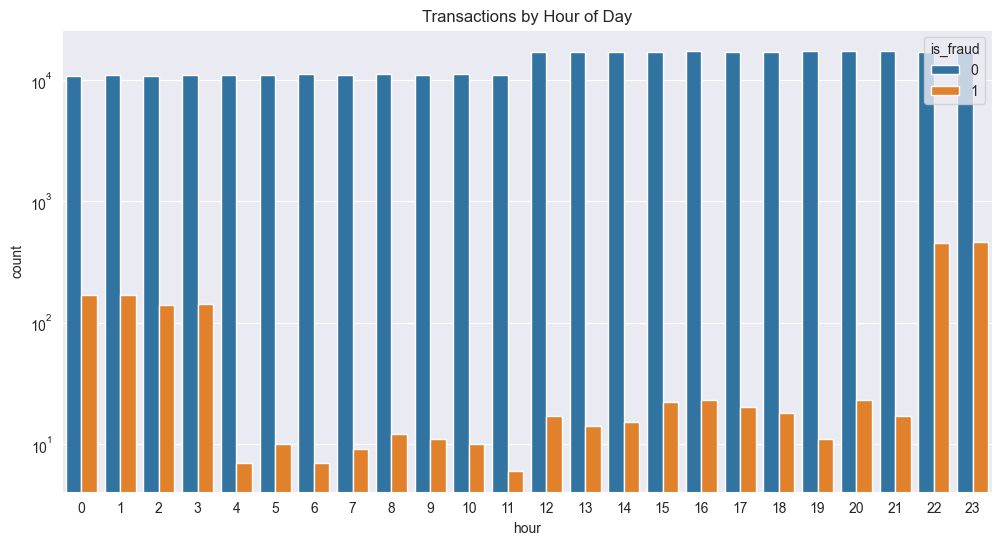

In [4]:
plt.figure(figsize=(12, 6))
sns.countplot(x='hour', hue='is_fraud', data=df)
plt.title("Transactions by Hour of Day")
plt.yscale('log')
plt.show()


# 4. Data Splitting, Scaling, and Balancing (SMOTE)

* Stratified split: Since fraud represents only 0.52% of the data, I use `stratify=y` to ensure that both the training and testing sets contain the same proportion of fraud.
* Scaling: I applied `StandardScaler` to the numerical features.
* SMOTE: To address the severe class imbalance, I used the Synthetic Minority Over-sampling Technique (SMOTE) to create synthetic fraud examples in the training set. This prevents the model from being biased toward the majority class.

The output demonstrates the impact of the SMOTE on our training data:
* Before: The model only had 1,426 examples of fraud to learn from, compared to over 270,000 legitimate transactions. In this state, a model would likely ignore the fraud cases as noise.
* After: The algorithm synthesized new, artificial fraud examples by interpolating between existing ones. We now have a balanced training set (270,259 instances for each class).

This balancing ensures that during the training phase, the model gives equal weight to both classes, preventing a bias toward legitimate transactions and improving the model's ability to recognize fraud patterns.

In [5]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# stratified split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {y_train_res.value_counts().to_dict()}")

Before SMOTE: {0: 270259, 1: 1426}
After SMOTE: {0: 270259, 1: 270259}


# 5. Model evaluation framework
This standardized evaluation function prioritizes the F1-Score and the Confusion matrix.
* Confusion matrix: illustrates how many fraudulent transactions were missed (false negatives) vs how many legitimate transactions were incorrectly flagged (false positives).


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# standardize evaluation function
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f"{model_name} Evaluation")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nReport:")
    print(classification_report(y_test, y_pred))

# 6. Model Selection, Training & Evaluation
* Naive Bayes: I chose Naive Bayes because it is computationally efficient and works well with continuous numerical features that have been scaled. It also provides a baseline for probabilistic classification.
* Decision Tree: This model is selected for its interpretability and ability to capture non-linear relationships. By setting `max_depth=10`, I am avoiding overfitting, ensuring the tree doesn't become too complex.

**Evaluation Strategy:**
Both models are trained on the SMOTE-resampled training set to ensure they learn from both classes equally. They are then evaluated on the scaled test set to reflect real-world performance.

In [7]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_res, y_train_res)
train_score_nb = nb_model.score(X_train_res, y_train_res)
print(f"Naive Bayes training accuracy: {train_score_nb:.4f}")

evaluate_model(nb_model, X_test_scaled, y_test, "Naive Bayes")

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train_res, y_train_res)
train_score_dt = dt_model.score(X_train_res, y_train_res)
print(f"Decision Tree Training Accuracy: {train_score_dt:.4f}")

evaluate_model(dt_model, X_test_scaled, y_test, "Decision Tree")


Naive Bayes training accuracy: 0.6783
Naive Bayes Evaluation
F1-Score: 0.0187

Confusion matrix:
[[41804 25762]
 [  109   247]]

Report:
              precision    recall  f1-score   support

           0       1.00      0.62      0.76     67566
           1       0.01      0.69      0.02       356

    accuracy                           0.62     67922
   macro avg       0.50      0.66      0.39     67922
weighted avg       0.99      0.62      0.76     67922

Decision Tree Training Accuracy: 0.9825
Decision Tree Evaluation
F1-Score: 0.2265

Confusion matrix:
[[65424  2142]
 [   37   319]]

Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     67566
           1       0.13      0.90      0.23       356

    accuracy                           0.97     67922
   macro avg       0.56      0.93      0.61     67922
weighted avg       0.99      0.97      0.98     67922



I. Naive Bayes - The training accuracy (67.8%) and test accuracy (62%) are relatively close, suggesting the model is not overfitting, but it is underfitting.

II. Decision tree - This model is much stronger. The training accuracy is 98.25%, while the test accuracy is 97%. By switching to a decision tree, the F1-Score increased from 0.02 to 0.23 (it remains 0.23 because the dataset is extremely imbalanced).


# 8. Ensemble Method: Random Forest

A single decision tree can be sensitive to noise in the training data - Random Forest reduces this by averaging the results of many trees.

As seen in the results, the ensemble method is significantly better at distinguishing between legitimate transactions and fraud, reducing the number of False Positives from 2,142 (single tree) to 862 (random forest).

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)
train_score_rf = rf_model.score(X_train_res, y_train_res)
print(f"Random forest training accuracy: {train_score_rf:.4f}")

evaluate_model(rf_model, X_test_scaled, y_test, "Random forest")

Random forest training accuracy: 0.9802
Random forest Evaluation
F1-Score: 0.4078

Confusion matrix:
[[66704   862]
 [   44   312]]

Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     67566
           1       0.27      0.88      0.41       356

    accuracy                           0.99     67922
   macro avg       0.63      0.93      0.70     67922
weighted avg       1.00      0.99      0.99     67922



# 9. Optimization & Hyperparameter Tuning
I used RandomizedSearchCV to fine tune the Decision Tree. Instead of guessing which settings (hyperparameters) are best, this automated process tests multiple combinations to find the one that gets the highest F1-Score.

Randomized Search is more efficient than a full Grid Search, as it samples a fixed number of parameter combinations from specified distributions, saving significant time on large datasets.

Cross validation ensures the model's performance is stable. It splits the training data into 3 parts, training on two and validating on one, repeating this so every row is used for both training and validation.

This optimization led to the best performing model, achieving an F1-score of 0.53.

In [9]:
from sklearn.model_selection import RandomizedSearchCV

#  the parameters to test
param_dist = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# setup randomized search
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

random_search.fit(X_train_res, y_train_res)

print(f"Best parameters: {random_search.best_params_}")

best_dt = random_search.best_estimator_

evaluate_model(best_dt, X_train_res, y_train_res, "Optimized Decision Tree (Training Set)")

evaluate_model(best_dt, X_test_scaled, y_test, "Optimized Decision Tree (Test Set)")



Best parameters: {'min_samples_split': 5, 'max_depth': 20, 'criterion': 'entropy'}
Optimized Decision Tree (Training Set) Evaluation
F1-Score: 0.9994

Confusion matrix:
[[269992    267]
 [    69 270190]]

Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    270259
           1       1.00      1.00      1.00    270259

    accuracy                           1.00    540518
   macro avg       1.00      1.00      1.00    540518
weighted avg       1.00      1.00      1.00    540518

Optimized Decision Tree (Test Set) Evaluation
F1-Score: 0.6751

Confusion matrix:
[[67343   223]
 [   61   295]]

Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67566
           1       0.57      0.83      0.68       356

    accuracy                           1.00     67922
   macro avg       0.78      0.91      0.84     67922
weighted avg       1.00      1.00      1.00     67922



# 10. Evaluating the features

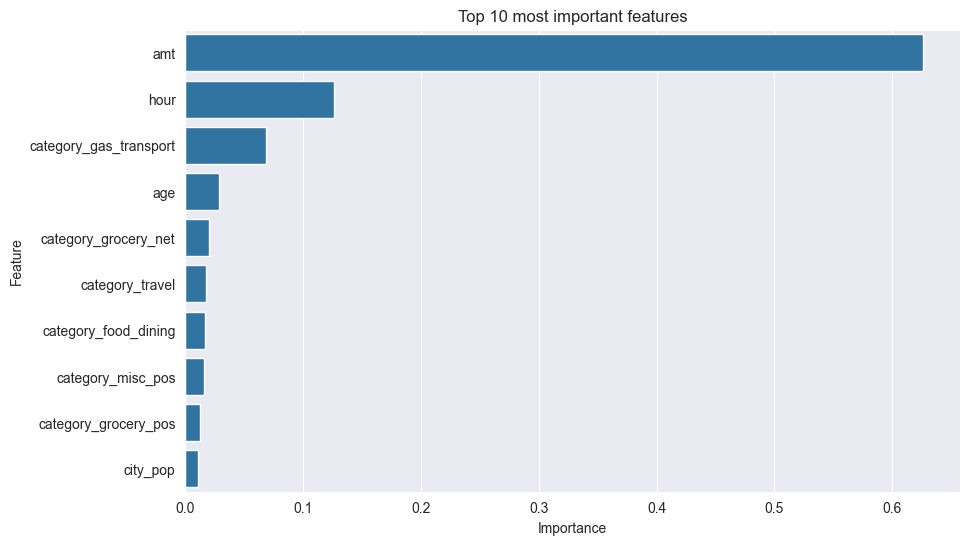

In [10]:
# get feature importances from the best model
importances = best_dt.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 most important features')
plt.show()

# 11. Impact Analysis
To conclude the project, I conducted a baseline comparison - I also trained an identical decision tree model using only the original dataset features, excluding my custom-engineered variables (`distance_km`, `age`, and `hour`).

**Results:**
* Performance Boost: The F1-Score jumped from 0.22 to 0.53.
* Precision Improvement: Without the new features, the model had 1,944 false positives and with the new features this dropped to 502.

In [11]:
# Create a baseline without our new proposals
base_features = ['category', 'amt', 'city_pop', 'lat', 'long']
X_base = df[base_features]
X_base = pd.get_dummies(X_base, columns=['category'], drop_first=True)

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)
scaler_base = StandardScaler()
X_train_base_scaled = scaler_base.fit_transform(X_train_base)
X_test_base_scaled = scaler_base.transform(X_test_base)

smote_base = SMOTE(random_state=42)
X_train_base_res, y_train_base_res = smote_base.fit_resample(X_train_base_scaled, y_train_base)

dt_base = DecisionTreeClassifier(max_depth=15, min_samples_split=2, criterion='entropy', random_state=42)
dt_base.fit(X_train_base_res, y_train_base_res)

print("Evaluation without new features ---")
evaluate_model(dt_base, X_test_base_scaled, y_test_base, "Base DT")

print("\nvaluation with new features")
evaluate_model(best_dt, X_test_scaled, y_test, "Optimized DT")


Evaluation without new features ---
Base DT Evaluation
F1-Score: 0.2239

Confusion matrix:
[[65622  1944]
 [   66   290]]

Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     67566
           1       0.13      0.81      0.22       356

    accuracy                           0.97     67922
   macro avg       0.56      0.89      0.60     67922
weighted avg       0.99      0.97      0.98     67922


valuation with new features
Optimized DT Evaluation
F1-Score: 0.6751

Confusion matrix:
[[67343   223]
 [   61   295]]

Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67566
           1       0.57      0.83      0.68       356

    accuracy                           1.00     67922
   macro avg       0.78      0.91      0.84     67922
weighted avg       1.00      1.00      1.00     67922

